In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib

In [4]:
df = pd.read_csv("credit_card_fraud_synthetic.csv")
df

,Time,V1,V2,V3,V4,V5,Amount,Class
0,121958,-2.289061,-1.313758,-0.452562,-0.392802,0.224787,1600.89,0
1,146867,1.432482,-1.095302,-0.129910,-1.362911,-1.017335,4191.85,0
2,131932,1.214722,-0.168797,0.581433,0.699020,0.964415,3271.32,0
3,103694,-0.880864,0.110956,-0.203236,-0.243510,0.362543,1377.51,0
4,119879,-0.881879,0.786970,1.110118,0.015365,-1.135162,4838.72,0
...,...,...,...,...,...,...,...,...
995,150168,-0.239297,-0.093612,0.674449,-1.934307,0.201932,1863.34,0
996,67728,-0.717823,0.704535,0.347665,0.158832,-0.295808,1152.10,0
997,165088,-0.484361,1.489765,-0.921505,-0.624253,1.588061,2805.25,0
998,11246,1.053057,-0.885100,-0.391480,0.000222,-0.077757,672.88,0


In [6]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1000, 8)
     Time        V1        V2        V3        V4        V5   Amount  Class
0  121958 -2.289061 -1.313758 -0.452562 -0.392802  0.224787  1600.89      0
1  146867  1.432482 -1.095302 -0.129910 -1.362911 -1.017335  4191.85      0
2  131932  1.214722 -0.168797  0.581433  0.699020  0.964415  3271.32      0
3  103694 -0.880864  0.110956 -0.203236 -0.243510  0.362543  1377.51      0
4  119879 -0.881879  0.786970  1.110118  0.015365 -1.135162  4838.72      0



Class Distribution:
Class
0    982
1     18
Name: count, dtype: int64


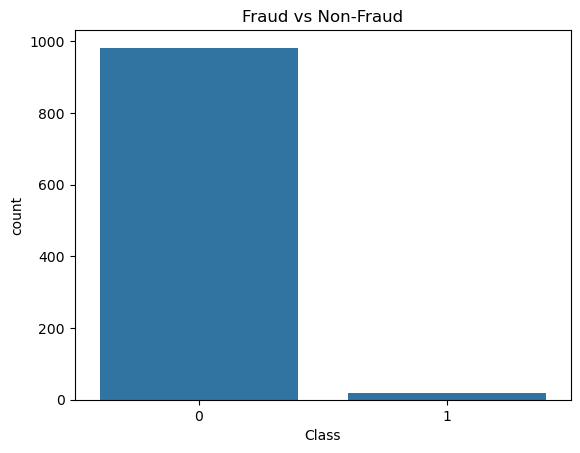

In [8]:
# 3. Check Class Imbalance
print("\nClass Distribution:")
print(df['Class'].value_counts())
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

In [10]:
# 4. Feature & Target Split
X = df.drop(columns=['Class'])
y = df['Class']

In [12]:
# 5. Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [14]:
# 6. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# 7. Baseline Model: Logistic Regression
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

print(classification_report(y_test, log_preds, zero_division=0))


              precision    recall  f1-score   support

           0       0.98      0.62      0.76       196
           1       0.01      0.25      0.03         4

    accuracy                           0.61       200
   macro avg       0.49      0.43      0.39       200
weighted avg       0.96      0.61      0.74       200



In [ ]:
# 8. Random Forest Model
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)
rf_preds = rf_model.predict(X_test)

print(classification_report(y_test, rf_preds, zero_division=0))


In [ ]:
# 9. Feature Importance Plot
importances = rf_model.feature_importances_
feature_names = df.drop(columns=['Class']).columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()
# 10. Save Model
joblib.dump(rf_model, "random_forest_fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved successfully!")